# 🧩 Instance-Based vs Model-Based Learning

> *Two ways to learn: memorize every example you've ever seen, or study them once and extract the underlying principle.*

## 🎯 In One Line

Machine Learning has two fundamental approaches to turning data into predictions: **Instance-Based Learning** and **Model-Based Learning**. The core difference is *how* the data is processed and *how* decisions get made from it.

> 💡 **Human analogy:** Think about how humans learn. Some people learn by **memorizing** — recalling specific past examples to answer a new question. Others learn by **understanding the underlying principle** — once they grasp the rule, they can apply it to situations they've never seen before. Machine learning models split the same way: instance-based models memorize data points, while model-based models extract the underlying pattern.

## 🗺️ Overview

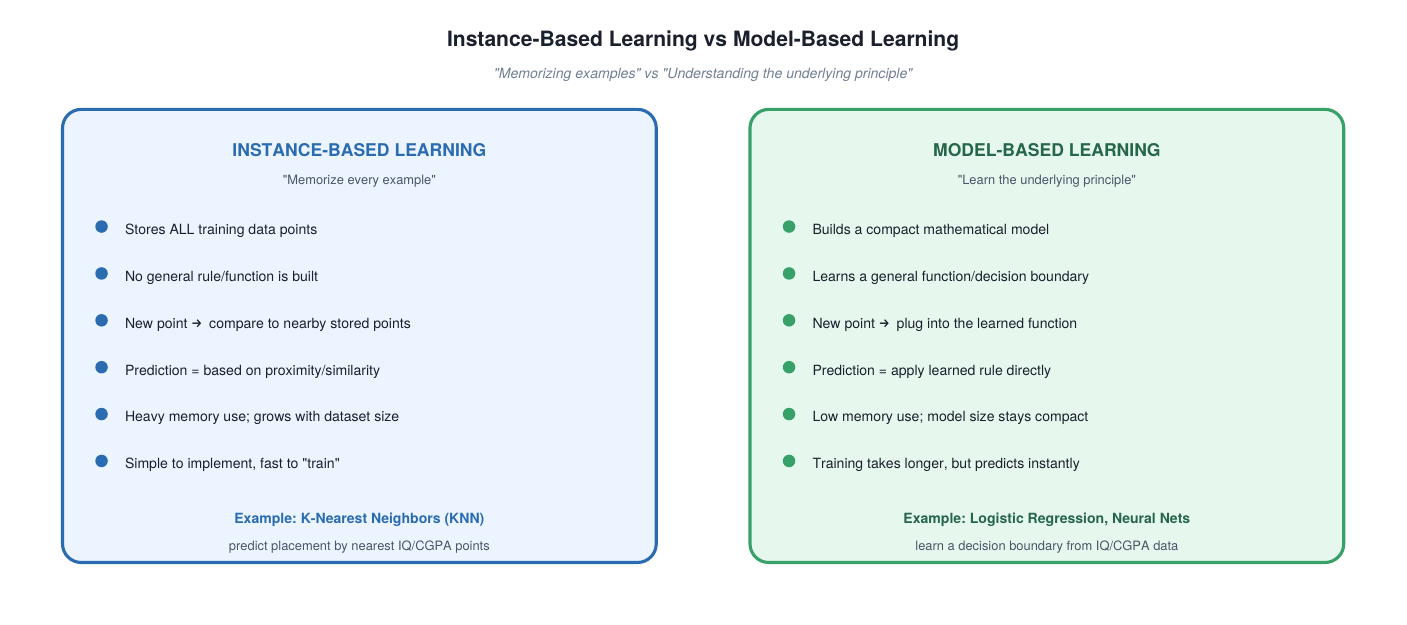

## 1️⃣ Instance-Based Learning

**Definition:** The model learns directly from the data by **memorizing individual examples (instances)**, rather than building a general rule or function. To make a prediction on new input, it directly compares that input against previously stored instances.

### How It Works
1. The model stores previous data points as-is — no general model/function is ever built.
2. When new data arrives, it's compared against the *nearest* stored instances, and a decision is made based on that comparison.

### 📊 Example: Predicting Placement from IQ and CGPA

Imagine classifying whether a student gets **placed** or **not placed**, based on their **IQ** and **CGPA**.

| Student | IQ | CGPA | Placed? |
|---|---|---|---|
| A | 118 | 3.7 | ✅ Yes |
| B | 90  | 2.4 | ❌ No |
| C | 130 | 3.9 | ✅ Yes |
| D | 85  | 2.1 | ❌ No |
| **New Student** | **112** | **3.4** | **?** |

An instance-based method like **K-Nearest Neighbors (KNN)** looks at the new student's (IQ, CGPA) point, finds the **k closest** students already stored in memory (e.g., Student A and C are closest), and predicts based on what *they* were labeled — no formula is learned, just a comparison to stored examples.

### ✅ Advantages
- Fast to "train" (there's really no training step — it just stores the data)
- Simple to implement

### ❌ Disadvantages
- Requires more memory and processing power for large datasets, since **all** training data must be kept and searched through for every single prediction

## 2️⃣ Model-Based Learning

**Definition:** The model builds a **general rule or function** from the data — commonly a mathematical model or decision boundary — which is then used to make predictions on new data. Here, the model learns the general *pattern* in the data rather than memorizing individual points.

### How It Works
1. The model builds a general pattern or function from the training data (e.g., fitting a decision boundary).
2. Once trained, the model uses this learned function to make decisions on any new data — no need to look back at the original training examples.

### 📊 Same Example, Model-Based Approach

Using the same IQ/CGPA placement data, a model-based method like **Logistic Regression** doesn't store the students at all after training. Instead, it learns a **decision boundary** — for example, roughly: *"if a weighted combination of IQ and CGPA crosses a certain threshold, predict 'Placed'."* For the new student (IQ 112, CGPA 3.4), the model just plugs these numbers into the learned formula and returns a prediction instantly — no comparison to past students needed.

### ✅ Advantages
- Easy and fast to predict on new data, since it's just applying a formula
- Once built, the model doesn't need to be retrained to make new predictions

### ❌ Disadvantages
- Can take significant time to build/train the model in the first place
- If the data is very complex, the model may not capture it accurately (risk of underfitting)

## ⚖️ Key Differences

| Feature | Instance-Based Learning | Model-Based Learning |
|---|---|---|
| Core idea | Memorize instances, compare new data to them | Learn a general rule/function from data |
| "Training" step | None really — just stores the data | Builds and tunes a model (parameters) |
| Prediction | Based on proximity/similarity to stored examples | Based on applying the learned function |
| Memory usage | High — must store all training data | Low — only the compact trained model is stored |
| Scalability | Struggles with very large datasets | Scales well to large datasets |
| Speed to predict | Can be slow (searches through stored data each time) | Fast (just evaluates a formula) |
| Generalization | Doesn't truly "learn" a rule — depends on stored data | Generalizes well to genuinely unseen data |
| Examples | K-Nearest Neighbors (KNN) | Linear Regression, Logistic Regression, Neural Networks |

> 📝 **Important nuance:** In Instance-Based Learning, the model is never really "trained" in the traditional sense — it just relies on its stored data instances every time. In Model-Based Learning, a specific, compact model is built that is capable of making predictions on new data without needing the original training set around.

> 🔧 **Shared requirement:** Regardless of which approach you use, **both require proper data preparation** — preprocessing, feature encoding, and (for model-based methods especially) careful parameter/hyperparameter tuning — for the learning to actually work well.

## 🐍 Python Example — KNN vs Logistic Regression, Side by Side

Using the same IQ/CGPA-style placement idea, the code below trains a **K-Nearest Neighbors** model (instance-based) and a **Logistic Regression** model (model-based) on the same synthetic dataset, then compares their **decision boundaries**, **model size in memory**, and **prediction speed** — directly illustrating the differences discussed above.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time
import sys
import pickle

# ------------------------------------------------------------------
# 1. Create a synthetic IQ/CGPA-style placement dataset
# ------------------------------------------------------------------
np.random.seed(42)
X, y = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.4, random_state=42
)
# Rescale features to look like IQ (80-140) and CGPA (2.0-4.0)
X_scaled = np.copy(X).astype(float)
X_scaled[:, 0] = 80 + (X[:, 0] - X[:, 0].min()) / (X[:, 0].max() - X[:, 0].min()) * 60   # IQ
X_scaled[:, 1] = 2.0 + (X[:, 1] - X[:, 1].min()) / (X[:, 1].max() - X[:, 1].min()) * 2.0  # CGPA

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

# ------------------------------------------------------------------
# 2. Train an Instance-Based model (KNN) and a Model-Based model (Logistic Regression)
# ------------------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

print(f"KNN test accuracy:                {accuracy_score(y_test, knn.predict(X_test)):.4f}")
print(f"Logistic Regression test accuracy: {accuracy_score(y_test, logreg.predict(X_test)):.4f}")

# ------------------------------------------------------------------
# 3. Compare stored model "size" -- KNN must keep the whole training set
# ------------------------------------------------------------------
knn_size = sys.getsizeof(pickle.dumps(knn))
logreg_size = sys.getsizeof(pickle.dumps(logreg))
print(f"\nModel size in memory (pickled):")
print(f"  KNN (stores all {len(X_train)} training points): {knn_size:,} bytes")
print(f"  Logistic Regression (just a formula):            {logreg_size:,} bytes")

# ------------------------------------------------------------------
# 4. Compare prediction speed on a single new student
# ------------------------------------------------------------------
new_student = np.array([[112, 3.4]])  # IQ 112, CGPA 3.4

t0 = time.perf_counter()
for _ in range(1000):
    knn.predict(new_student)
knn_time = (time.perf_counter() - t0) / 1000

t0 = time.perf_counter()
for _ in range(1000):
    logreg.predict(new_student)
logreg_time = (time.perf_counter() - t0) / 1000

print(f"\nAvg. prediction time per new student (1000 runs):")
print(f"  KNN:                  {knn_time*1e6:.2f} microseconds")
print(f"  Logistic Regression:  {logreg_time*1e6:.2f} microseconds")

print(f"\nPrediction for new student (IQ=112, CGPA=3.4):")
print(f"  KNN predicts:                 {'Placed' if knn.predict(new_student)[0] == 1 else 'Not Placed'}")
print(f"  Logistic Regression predicts: {'Placed' if logreg.predict(new_student)[0] == 1 else 'Not Placed'}")

KNN test accuracy:                0.9200
Logistic Regression test accuracy: 0.9867

Model size in memory (pickled):
  KNN (stores all 225 training points): 8,822 bytes
  Logistic Regression (just a formula):            753 bytes



Avg. prediction time per new student (1000 runs):
  KNN:                  1435.24 microseconds
  Logistic Regression:  88.02 microseconds

Prediction for new student (IQ=112, CGPA=3.4):
  KNN predicts:                 Placed
  Logistic Regression predicts: Placed


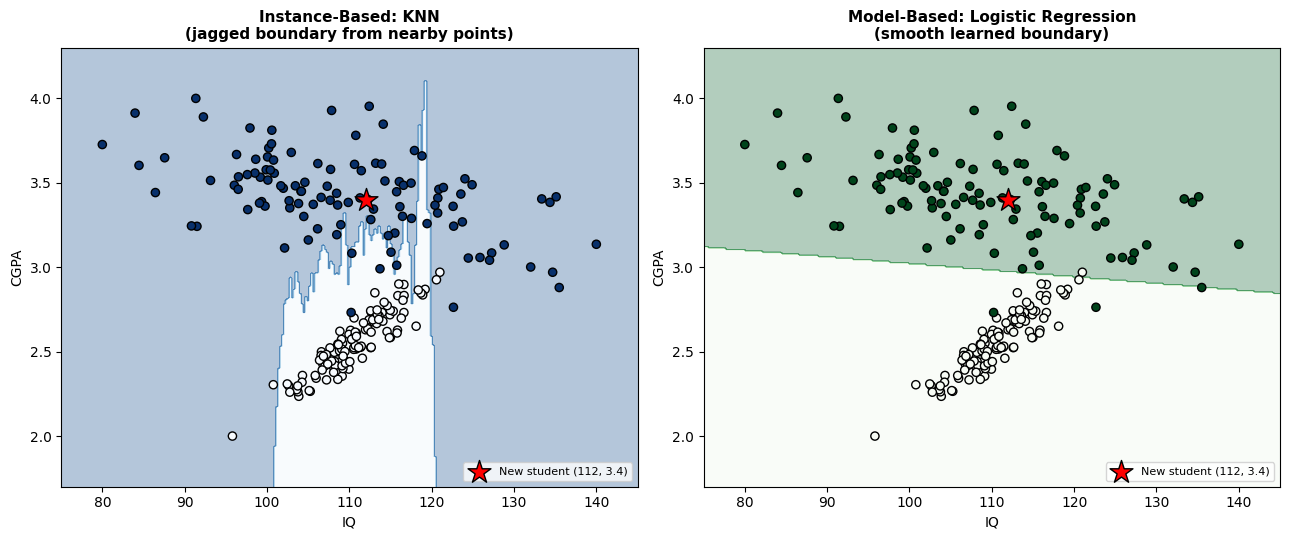

In [2]:
# ------------------------------------------------------------------
# 5. Visualize the decision boundaries side by side
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

x_min, x_max = X_scaled[:, 0].min() - 5, X_scaled[:, 0].max() + 5
y_min, y_max = X_scaled[:, 1].min() - 0.3, X_scaled[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, model, title, color in [
    (axes[0], knn, "Instance-Based: KNN\n(jagged boundary from nearby points)", "Blues"),
    (axes[1], logreg, "Model-Based: Logistic Regression\n(smooth learned boundary)", "Greens"),
]:
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=color)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=color, edgecolor="k", s=35)
    ax.scatter(112, 3.4, c="red", marker="*", s=300, edgecolor="black", label="New student (112, 3.4)")
    ax.set_xlabel("IQ")
    ax.set_ylabel("CGPA")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("decision_boundaries.png", dpi=130, bbox_inches="tight")
plt.show()

### 🔍 Code Explanation

| Step | What It Shows |
|---|---|
| **Synthetic IQ/CGPA data** | A 2D dataset is rescaled to look like realistic IQ (80-140) and CGPA (2.0-4.0) values |
| **KNN vs Logistic Regression** | Both are trained on the exact same data, so any difference in behavior comes purely from the *approach*, not the data |
| **Model size comparison** | KNN's pickled size scales with the training set (it must store all points), while Logistic Regression stores only a few learned coefficients — a direct, measurable illustration of the memory-usage difference |
| **Prediction speed** | KNN must search through stored neighbors at prediction time; Logistic Regression just evaluates a formula — this is why model-based methods usually predict faster in production |
| **Decision boundary plot** | KNN's boundary tends to look jagged/irregular (following the local neighborhood structure), while Logistic Regression's boundary is a single smooth line (since it learned one global function) |

> 🧠 **Notice:** Both models can reach similar accuracy on simple data like this — the real differences show up in **memory footprint**, **prediction speed at scale**, and **how well each generalizes to more complex, less-clean real-world data**.

## 🧠 Quick Revision Questions

1. In Instance-Based Learning, is the model ever really "trained" in the traditional sense? Why or why not?
2. Why does KNN's memory usage grow with the size of the training set, while Logistic Regression's doesn't?
3. In the IQ/CGPA example, how would KNN and Logistic Regression each classify a brand-new student differently in terms of *process* (even if they give the same final answer)?
4. Why do model-based methods usually scale better to very large datasets?
5. What preprocessing step do *both* instance-based and model-based methods still require, regardless of their differences?